In [3]:
# ------------------------------
#        Milestone 1
# ------------------------------


In [4]:
#imported libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model

#dataset loading 
df = pd.read_csv("../data/gold_historical_data.csv")
df.head()
df_original = df.copy()

In [5]:
#info about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2510 entries, 0 to 2509
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2510 non-null   object 
 1   Adj Close  2510 non-null   float64
 2   Close      2510 non-null   float64
 3   High       2510 non-null   float64
 4   Low        2510 non-null   float64
 5   Open       2510 non-null   float64
 6   Volume     2510 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 137.4+ KB


In [6]:
#stats
df.describe()

,Adj Close,Close,High,Low,Open,Volume
count,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000,2510.000000
mean,1862.680556,1862.680556,1872.036176,1852.944064,1862.260478,5161.460558
std,713.045002,713.045002,719.366255,706.561716,712.946710,28443.386437
min,1127.800049,1127.800049,1132.800049,1123.900024,1126.900024,0.000000
25%,1306.224976,1306.224976,1310.325043,1301.624969,1306.224976,53.250000
50%,1767.350037,1767.350037,1777.200012,1759.900024,1768.049988,213.000000
75%,1968.975006,1968.975006,1978.375031,1960.599976,1969.325012,655.500000
max,5318.399902,5318.399902,5586.200195,5301.600098,5415.700195,386334.000000


In [7]:
#missing value check
df.isnull().sum()

Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [8]:
#date column coversion
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
#added year feature to see in which year price was up
df['Year'] = df['Date'].dt.year
df['Month']   = df['Date'].dt.month      
df['Day']     = df['Date'].dt.day        
df['Weekday'] = df['Date'].dt.weekday    
df.columns
df.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Day,Weekday
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2016,2,5,4
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2016,2,8,0
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2016,2,9,1
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2016,2,10,2
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2016,2,11,3


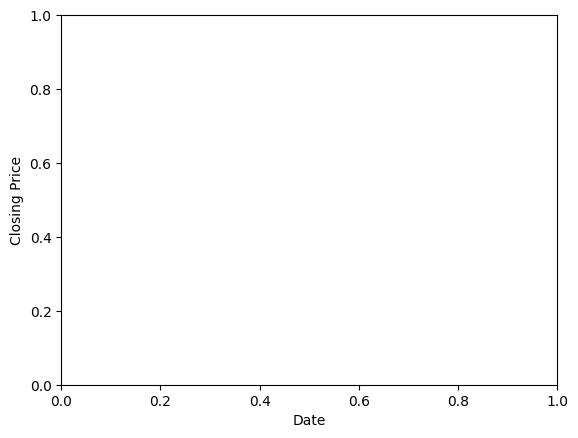

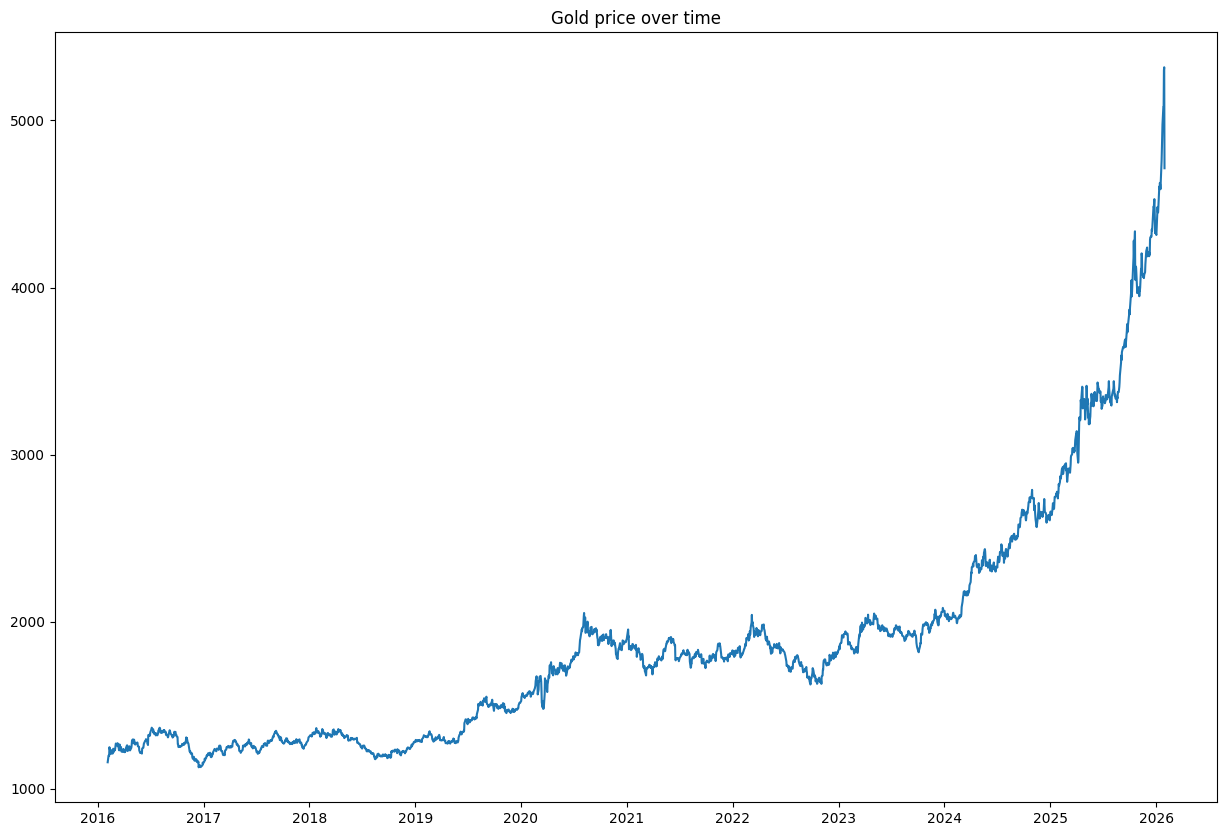

In [10]:
#gold price over time - Visualization 1

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.figure(figsize=(15,10))
plt.title("Gold price over time")
plt.plot(df['Date'], df['Close'])
plt.show()


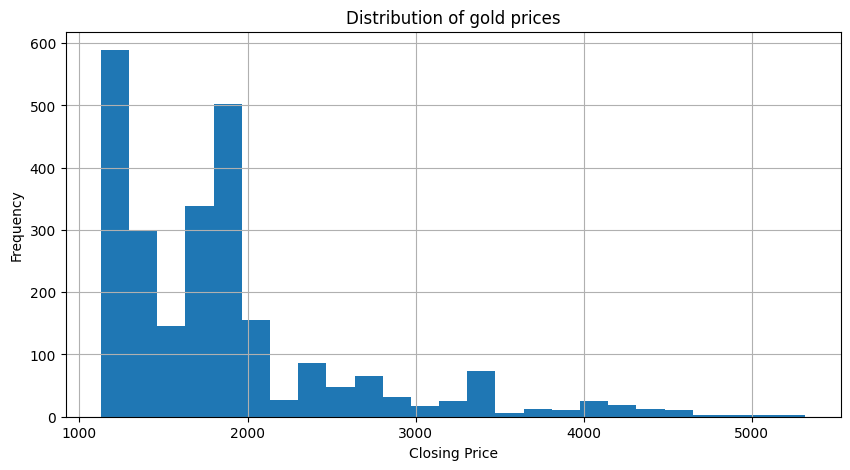

In [11]:
#price distribution - histogram - 2
plt.figure(figsize=(10,5))
plt.xlabel("Closing Price")
plt.ylabel("Frequency")
plt.title("Distribution of gold prices")
df['Close'].hist(bins=25)
plt.show()

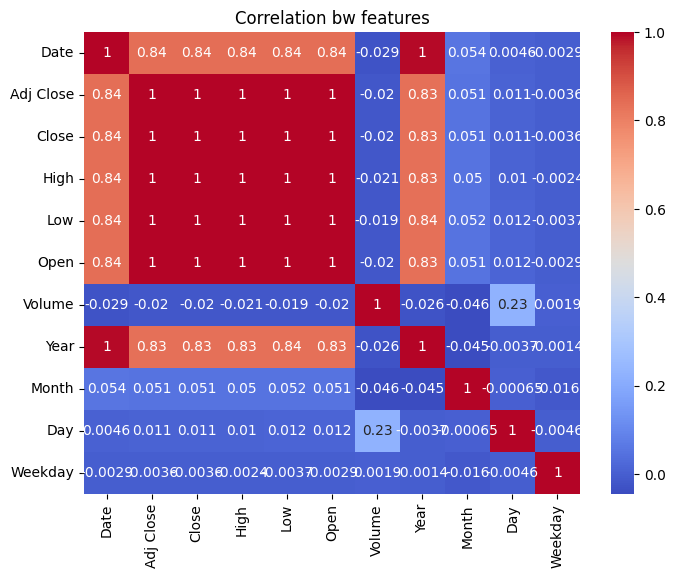

In [12]:
#correlation heatmap - 3
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation bw features")
plt.show()

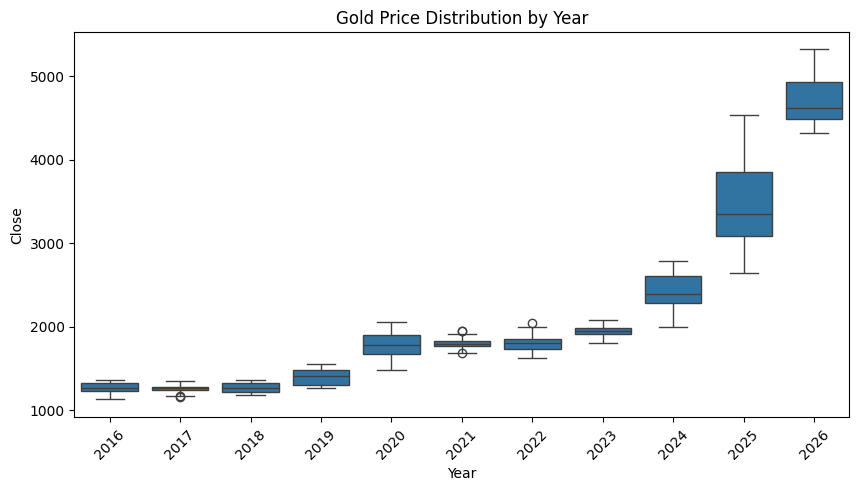

In [13]:
#closing price per year - boxplot- 4

plt.figure(figsize=(10,5))
plt.title("Gold Price Distribution by Year")
sns.boxplot(x='Year', y='Close', data=df)
plt.xticks(rotation=45)
plt.show()


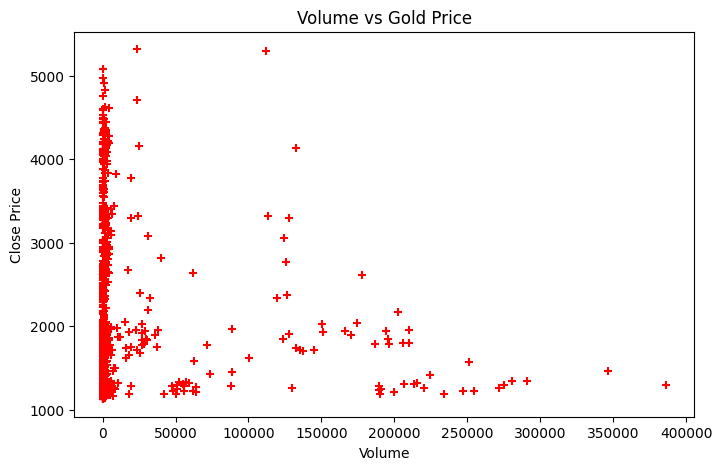

In [14]:
#to see relationship bw trading volume and closing price - scatter plot -5
plt.figure(figsize=(8,5))
plt.scatter(df['Volume'], df['Close'], color = 'red', marker='+')
plt.title("Volume vs Gold Price")
plt.xlabel("Volume")
plt.ylabel("Close Price")
plt.show()

In [15]:
# ------------------------------
#         Milestone 2
# ------------------------------


In [16]:
# check missing values
df.isnull().sum()


Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
Year         0
Month        0
Day          0
Weekday      0
dtype: int64

In [17]:
df.columns 
# Encoding categorical variables
# The dataset does not contain categorical variables,
# so this step is not required.

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume', 'Year',
       'Month', 'Day', 'Weekday'],
      dtype='object')

In [18]:
# Feature Eng - Extracting  month, day and weekday from date
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['Weekday'] = df['Date'].dt.weekday

df.head()


,Date,Adj Close,Close,High,Low,Open,Volume,Year,Month,Day,Weekday
0,2016-02-05,1157.800049,1157.800049,1174.800049,1146.000000,1155.599976,877,2016,2,5,4
1,2016-02-08,1197.900024,1197.900024,1200.400024,1165.000000,1173.500000,931,2016,2,8,0
2,2016-02-09,1198.699951,1198.699951,1199.199951,1186.699951,1188.699951,700,2016,2,9,1
3,2016-02-10,1194.699951,1194.699951,1197.699951,1182.099976,1189.800049,671,2016,2,10,2
4,2016-02-11,1247.900024,1247.900024,1260.800049,1204.599976,1205.599976,995,2016,2,11,3


In [19]:
X = df[['Open','High','Low','Volume','Year','Month','Day','Weekday']]
y = df['Close']

In [20]:
#Scaling features
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)


In [21]:
from sklearn.model_selection import train_test_split

# train and temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# validation and test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (1757, 8)
Validation size: (602, 8)
Test size: (151, 8)


In [22]:
# ------------------------------
#        Milestone 3
# ------------------------------

In [23]:
# model created
model = linear_model.LinearRegression()

# training model 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
y_pred = model.predict(X_test)

In [25]:
#Baseline Metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)


MSE: 58.94143556981787
RMSE: 7.677332581686029
MAE: 4.4470170021109725


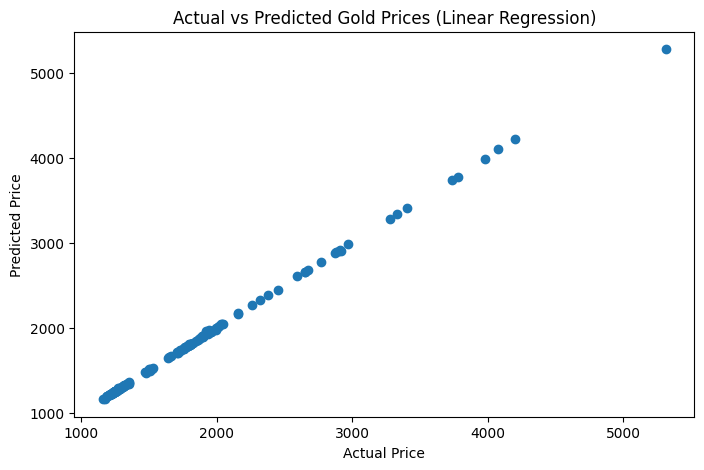

In [26]:
#Plotting to see Actual vs Predicted Prices

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Gold Prices (Linear Regression)")
plt.show()


In [27]:
# ------------------------------
#        Milestone 4
# ------------------------------

In [28]:
#--------Some feature engineering and target variable creation for classification task--------
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
from xgboost import XGBClassifier

#doing feature engineering on original df to avoid data leakage
df = df_original.copy()
df['Date']= pd.to_datetime(df['Date'])
df['Year']= df['Date'].dt.year
df['Month']= df['Date'].dt.month
df['Weekday']= df['Date'].dt.weekday

# Prev_Close is the closing price of the previous day, used to calculate returns and volatility, using it here to avoid data leakage in features
df['Prev_Close']= df['Close'].shift(1)
df['Return_1d']= df['Prev_Close'].pct_change(1)   # 1 day return
df['Return_5d']= df['Prev_Close'].pct_change(5)   # 5 day return
df['Vol_5d']= df['Prev_Close'].rolling(5).std() # 5 day std deviation as volatility
df['Vol_Ratio']= df['Prev_Close'].rolling(5).std() / df['Prev_Close'].rolling(20).std()  # ratio is of short vs long volatility
df['Z_Score_20']= (df['Prev_Close'] - df['Prev_Close'].rolling(20).mean()) / df['Prev_Close'].rolling(20).std()  # Z_Score is mean reverse signal
#it tells us how many standard deviations the current price is from its 20-day moving average.

# RSI means Relative Strength Index, it measures the speed and change of price movements. 
delta= df['Prev_Close'].diff() #calculated daily price change
gain= delta.where(delta > 0, 0).rolling(14).mean() #positive changes average
loss= (-delta.where(delta < 0, 0)).rolling(14).mean()#negative changes average
df['RSI']= 100 - (100 / (1 + (gain / loss).replace(np.inf, 0)))

# Target column to tell, 1 for  price UP, 0 for price DOWN 
df['Target']= (df['Close'].pct_change() > 0).astype(int)

# NaN rows drop due to rolling windows 
df.dropna(inplace=True)

features = ['Return_1d', 'Return_5d', 'Vol_5d', 'Vol_Ratio', 'Z_Score_20', 'RSI']
X= df[features]
y= df['Target']

print('Dataset shape:', X.shape)
print('\nClass balance (0=Down, 1=Up):')
print(y.value_counts())

Dataset shape: (2490, 6)

Class balance (0=Down, 1=Up):
Target
1    1343
0    1147
Name: count, dtype: int64


In [29]:
#-----Learnt and Used Chronological split to maintain time order and avoid data leakage-----
split_idx= int(len(df) * 0.8)
X_train, X_test= X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test= y.iloc[:split_idx], y.iloc[split_idx:]
#iloc here means we are selecting rows based on their integer position in the DataFrame.

# scaling using robustscaler as it is less sensitive to outliers, which are like common in financial data instead of minmax or standard scaler
scaler= RobustScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_test_scaled= scaler.transform(X_test)  # so that test data is scaled based on train data stats

print(f'Train:{X_train.shape[0]} samples')
print(f'Test:{X_test.shape[0]} samples')
print(f'Train dates:{df["Date"].iloc[:split_idx].min().date()} → {df["Date"].iloc[:split_idx].max().date()}')
print(f'Test dates:{df["Date"].iloc[split_idx:].min().date()} → {df["Date"].iloc[split_idx:].max().date()}')

Train:1992 samples
Test:498 samples
Train dates:2016-03-07 → 2024-02-07
Test dates:2024-02-08 → 2026-01-30


In [30]:
#---------Hyperparameter tuning using cross validation----------

#Class imbalance check
print('Class balance:')
print(y_train.value_counts())

#giving more importance to minority class 
scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nscale_pos_weight: {scale_pos_weight:.2f}')

#TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

param_dist = {
    'n_estimators':[100, 200, 300, 400],
    'max_depth':[3, 4, 5, 6],
    'learning_rate':[0.01, 0.03, 0.05, 0.1],
    'subsample':[0.7, 0.8, 0.9],
    'colsample_bytree':[0.7, 0.8, 1.0],
    'gamma':[0, 0.1, 0.2],
}


base_model= XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42
)

#trying 30 combinations
search= RandomizedSearchCV(
    estimator= base_model,
    param_distributions= param_dist,
    n_iter= 30,
    scoring='f1',
    cv= tscv,
    n_jobs= -1,
    random_state=42,
    verbose= 1
)

#training the model with hyperparameter tuning
search.fit(X_train_scaled, y_train)

print('\nBest hyperparameters:')
for k, v in search.best_params_.items():
    print(f'{k}:{v}')
print(f'\nBest CV F1:{search.best_score_:.4f}')

Class balance:
Target
1    1047
0     945
Name: count, dtype: int64

scale_pos_weight: 0.90
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best hyperparameters:
subsample:0.9
n_estimators:400
max_depth:5
learning_rate:0.1
gamma:0.1
colsample_bytree:0.7

Best CV F1:0.5008


Optimal threshold: 0.350

--- Classification Report ---
              precision    recall  f1-score   support

  Price Down       0.46      0.37      0.41       202
    Price Up       0.62      0.71      0.66       296

    accuracy                           0.57       498
   macro avg       0.54      0.54      0.53       498
weighted avg       0.56      0.57      0.56       498



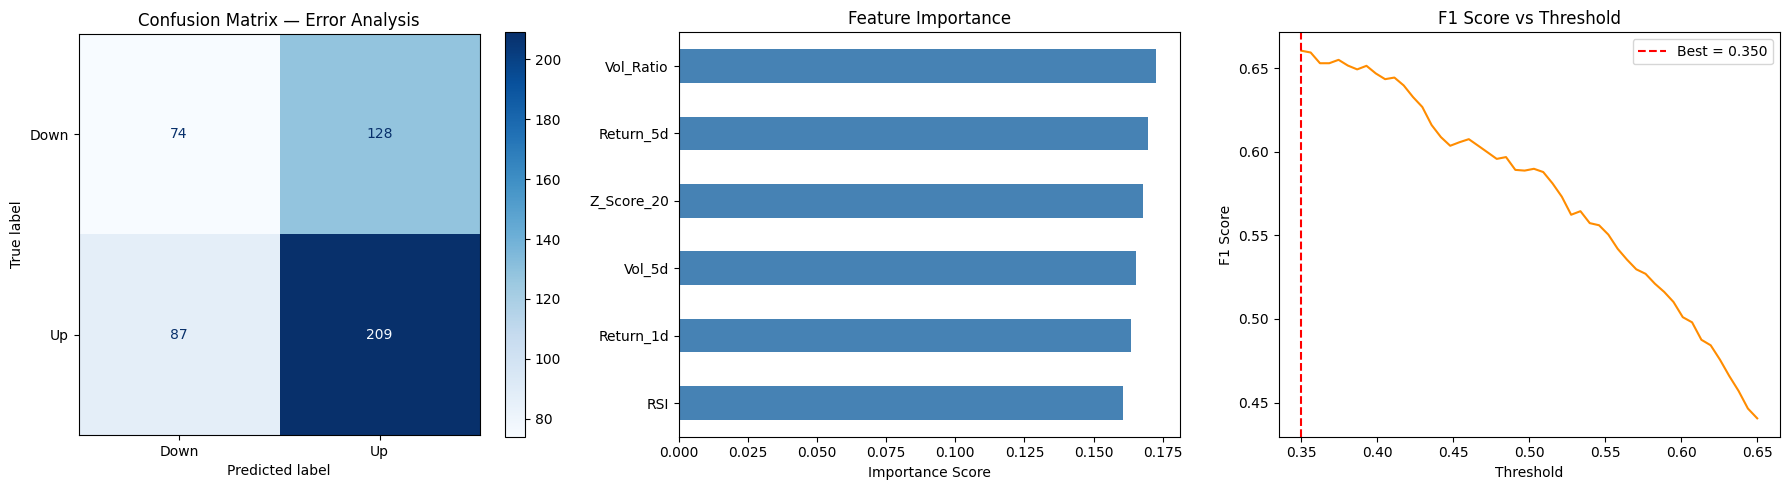

In [31]:
#-------------------Error Analysis--------------
#trained model with best hyperparameters
best_model= search.best_estimator_

#threshold tuning, finding the best point to classify price up vs down, instead of default 0.5
probs= best_model.predict_proba(X_test_scaled)[:, 1]
#will try on 50 values between 0.35 and 0.65 to find the best threshold 
thresholds= np.linspace(0.35, 0.65, 50)
scores= [f1_score(y_test, (probs > t).astype(int)) for t in thresholds]
best_thr= thresholds[np.argmax(scores)]
print(f'Optimal threshold: {best_thr:.3f}')
y_pred= (probs > best_thr).astype(int)

print('\n--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Price Down', 'Price Up']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Plot 1- Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Down', 'Up'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix — Error Analysis')

#Plot 2- Feature Importance
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importance')
axes[1].set_xlabel('Importance Score')

#Plot 3- F1 vs Threshold — best cutoff point
axes[2].plot(thresholds, scores, color='darkorange')
axes[2].axvline(best_thr, color='red', linestyle='--', label=f'Best = {best_thr:.3f}')
axes[2].set_title('F1 Score vs Threshold')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F1 Score')
axes[2].legend()

plt.tight_layout()
plt.show()

In [32]:
print("I used xgboost as it handles financial data better than random forest, also did some work to prevent data leakage and got 57% accuracy which is decent for financial data as random guess is 50% and financial data is very noisy. Xgboost also tracked which features were important in splits.") 

I used xgboost as it handles financial data better than random forest, also did some work to prevent data leakage and got 57% accuracy which is decent for financial data as random guess is 50% and financial data is very noisy. Xgboost also tracked which features were important in splits.


In [33]:
# ------------------------------
#        Milestone 5
# ------------------------------

In [34]:
# Comparing XGBoost with Random Forest to finalize best model as I tried random forest earlier but didn't show it- 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Random Forest with same chronological split
rf_model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=300,
    max_depth=5,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)

# XGBoost already trained
xgb_preds = y_pred  #from Milestone 4

print("Comparing both models on test set - ")
print(f"XGBoost  Accuracy : {accuracy_score(y_test, xgb_preds):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

print("\nRandom Forest Classification Report -")
print(classification_report(y_test, rf_preds, target_names=['Price Down', 'Price Up']))

print("\nXGBoost Classification Report -")
print(classification_report(y_test, xgb_preds, target_names=['Price Down', 'Price Up']))

print("\nConclusion - I chose XGBoost as final model due to better balance between Price Up and Price Down prediction.")

Comparing both models on test set - 
XGBoost  Accuracy : 0.5683
Random Forest Accuracy: 0.5321

Random Forest Classification Report -
              precision    recall  f1-score   support

  Price Down       0.44      0.60      0.51       202
    Price Up       0.64      0.48      0.55       296

    accuracy                           0.53       498
   macro avg       0.54      0.54      0.53       498
weighted avg       0.56      0.53      0.54       498


XGBoost Classification Report -
              precision    recall  f1-score   support

  Price Down       0.46      0.37      0.41       202
    Price Up       0.62      0.71      0.66       296

    accuracy                           0.57       498
   macro avg       0.54      0.54      0.53       498
weighted avg       0.56      0.57      0.56       498


Conclusion - I chose XGBoost as final model due to better balance between Price Up and Price Down prediction.


In [35]:
print("""
FINAL MODEL - XGBoost Classifier

STRENGTHS - 

1. I made sure the model never sees future data during training, so that there is no data leakage.
   I used Prev_Close (yesterday's price) to predict today's direction
   and split the data chronologically (first 80% = train, last 20% = test).

2. My dataset had more UP days than DOWN days, so i tried to manage data imbalance.
   I used scale_pos_weight to tell the model to pay more attention
   to DOWN days so it doesn't just always predict UP.

3. Instead of manually guessing parameters, I used RandomizedSearchCV
   which tested 30 different combinations automatically to do Hyperparameter tuning 
   and find the best settings for the model.
   I also used TimeSeriesSplit so even the CV folds respected time order.

4. My model got 57% accuracy, which I think is better than random guessing.
   In financial markets, randomly guessing UP or DOWN gives 50%.
   So 57% means the model is actually learning
   something useful from the data.

5. XGBoost shows feature importance. Vol_Ratio and Return_5d came out
   as the most useful features, which makes sense because volatility
   and recent returns do affect gold price direction.

LIMITATIONS:

1. The recall for Price Up is 71% but for Price Down it's only 37%.
   This is probably because gold prices have mostly gone up from
   2016 to 2024 in our training data, so the model learned that bias.

2. When the model says price will go DOWN, it is wrong more than
   half the time (precision 0.46). So I would not fully trust its
   DOWN predictions in real life.

3. I only used technical indicators like RSI, returns, and volatility.
   Gold price is also affected by things like inflation, USD value,
   and global news, which I have not yet included in my model, will probably try soon .

4. The best threshold came out to be 0.35 instead of the normal 0.5.
   This means the model is not very confident in its predictions and
   needs a low bar to say UP. A more confident model would work
   well at 0.5 itself. So, i think there is room of improvement there as well.

""")


FINAL MODEL - XGBoost Classifier

STRENGTHS - 

1. I made sure the model never sees future data during training, so that there is no data leakage.
   I used Prev_Close (yesterday's price) to predict today's direction
   and split the data chronologically (first 80% = train, last 20% = test).

2. My dataset had more UP days than DOWN days, so i tried to manage data imbalance.
   I used scale_pos_weight to tell the model to pay more attention
   to DOWN days so it doesn't just always predict UP.

3. Instead of manually guessing parameters, I used RandomizedSearchCV
   which tested 30 different combinations automatically to do Hyperparameter tuning 
   and find the best settings for the model.
   I also used TimeSeriesSplit so even the CV folds respected time order.

4. My model got 57% accuracy, which I think is better than random guessing.
   In financial markets, randomly guessing UP or DOWN gives 50%.
   So 57% means the model is actually learning
   something useful from the data.

